<a href="https://colab.research.google.com/github/sanad0123/MSDS686/blob/main/Sanjeeb_Adhikari_Deep_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Author: Sanjeeb Adhikari
### Subject: Deep Learning [MSDS686]

# Data Selection
The dataset used for this project is the Intel Image Classification dataset, sourced from Kaggle. It contains approximately 17,000 RGB images divided into training (seg_train) and testing (seg_test) sets. The images are categorized into six classes: buildings, forest, glacier, mountain, sea, and street.

In [2]:
import numpy as np
import pandas as pd
import os
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from keras import models, layers, backend, Input, Model
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Loading the dataset from Kaggle

In [3]:
! pip install kaggle -q

In [4]:
! mkdir ~/.kaggle

In [5]:
! cp kaggle.json ~/.kaggle/

In [6]:
! chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 83% 289M/346M [00:00<00:00, 587MB/s]
100% 346M/346M [00:00<00:00, 620MB/s]


In [8]:
train_dir = 'seg_train/seg_train'

# Get the list of class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
print(f"Found the following classes: {class_names}")

Found the following classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Viewing Dataset

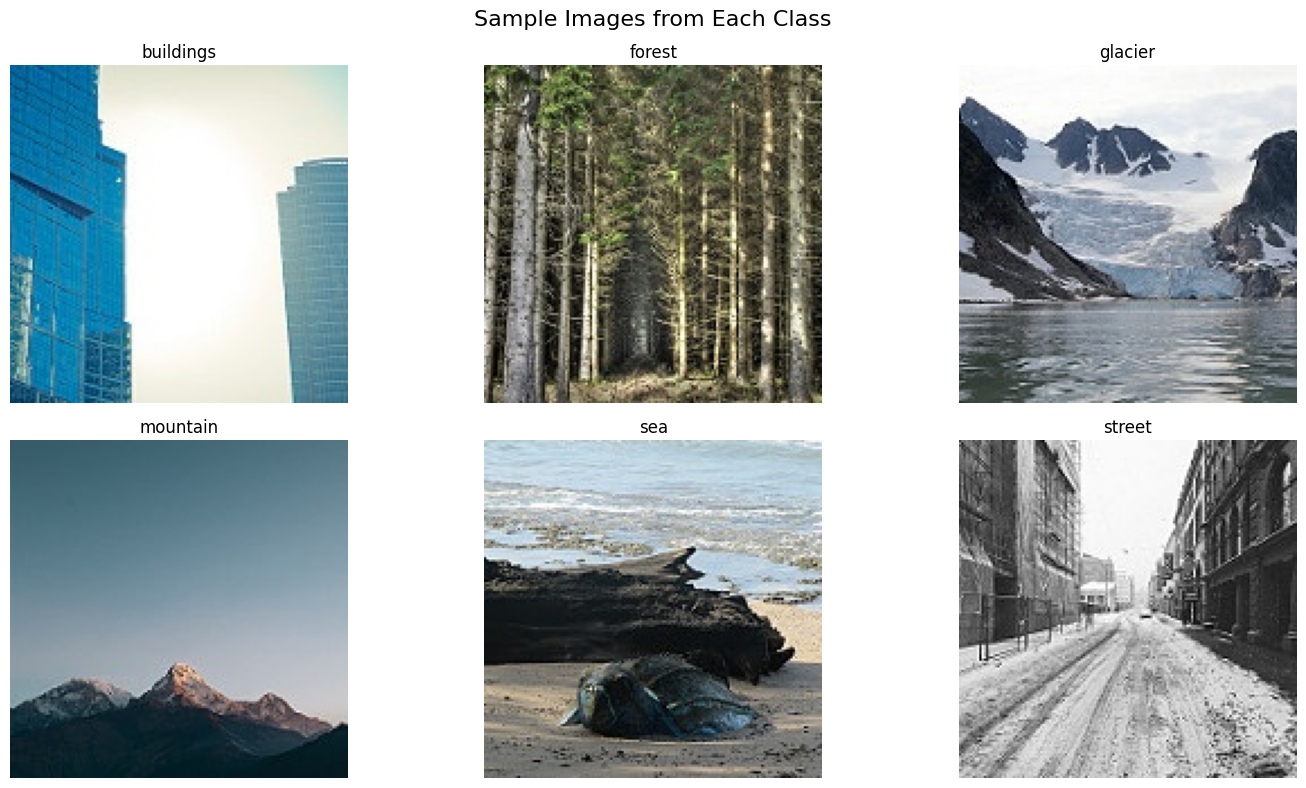

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sample Images from Each Class', fontsize=16)

# Loop through each class and display a random image
for i, class_name in enumerate(class_names):
    ax = axes.flatten()[i]
    class_dir = os.path.join(train_dir, class_name)

    # Get a random image from the class directory
    image_name = random.choice(os.listdir(class_dir))
    image_path = os.path.join(class_dir, image_name)

    # Read and display the image
    img = mpimg.imread(image_path)
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis('off') # Hide the axes

plt.tight_layout()
plt.show()

# Data Preparation
I used Keras’s ImageDataGenerator to prepare the dataset for modeling. Although the images were already 150×150, I resized them again to ensure consistency.


In [10]:
train_dir = 'seg_train/seg_train'
test_dir = 'seg_test/seg_test'
IMG_SIZE = (150, 150)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical' # For multi-class classification
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


# Building Base Model

I built a Convolutional Neural Network (CNN) using the Keras Sequential API.  
The model consists of three convolutional blocks followed by a fully connected layer and an output layer.  
Each convolutional block includes a Conv2D layer with ReLU activation and a MaxPooling2D layer to reduce spatial dimensions.  
The extracted features are then flattened and passed through a dense layer.  
Finally, an output layer with 6 neurons and softmax activation is used to classify images into six categories.


In [11]:
backend.clear_session()

model = tf.keras.models.Sequential([
    # First convolutional block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Second convolutional block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Third convolutional block
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),

    # Dense layer for classification
    tf.keras.layers.Dense(512, activation='relu'),

    # Output layer with 6 neurons for the 6 classes
    tf.keras.layers.Dense(6, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,742 (72.62 MB)

 Trainable params: 19,036,742 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

The model was compiled using the Adam optimizer and categorical cross-entropy loss, with accuracy as the performance metric.  
It was trained for 15 epochs to establish a baseline.  
For now, the test dataset is used as the validation set to monitor performance during training, but a separate validation split will be created later for more accurate evaluation.

In [12]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=15, # start with 15 epochs for the baseline
    validation_data=test_generator,
    verbose=1
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.5301 - loss: 1.2946 - val_accuracy: 0.6657 - val_loss: 0.8815
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.7410 - loss: 0.6901 - val_accuracy: 0.7833 - val_loss: 0.5933
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.8253 - loss: 0.4924 - val_accuracy: 0.7847 - val_loss: 0.5987
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.8875 - loss: 0.3277 - val_accuracy: 0.8163 - val_loss: 0.5536
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9300 - loss: 0.2035 - val_accuracy: 0.7987 - val_loss: 0.7197
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.9534 - loss: 0.1377 - val_accuracy: 0.7810 - val_loss: 0.8786
Epoch 7/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9641 - loss: 0.1112 - val_accuracy: 0.8020 - val_loss: 0.9368
Epoch 8/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9818 - loss: 0.0596 - val_accurac

In [13]:
loss, accuracy = model.evaluate(test_generator)
print(f"\nBaseline Model Accuracy on Test Data: {accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8076 - loss: 1.1745

Baseline Model Accuracy on Test Data: 80.43%


In [14]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Accuracy plot
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss plot
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


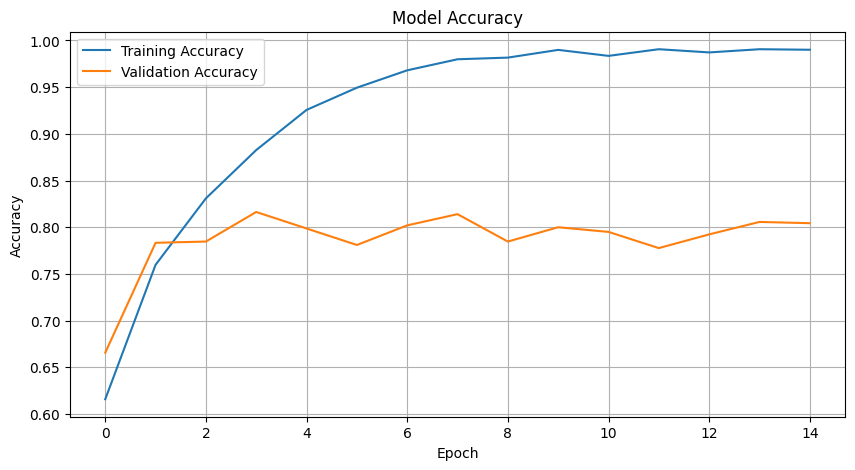

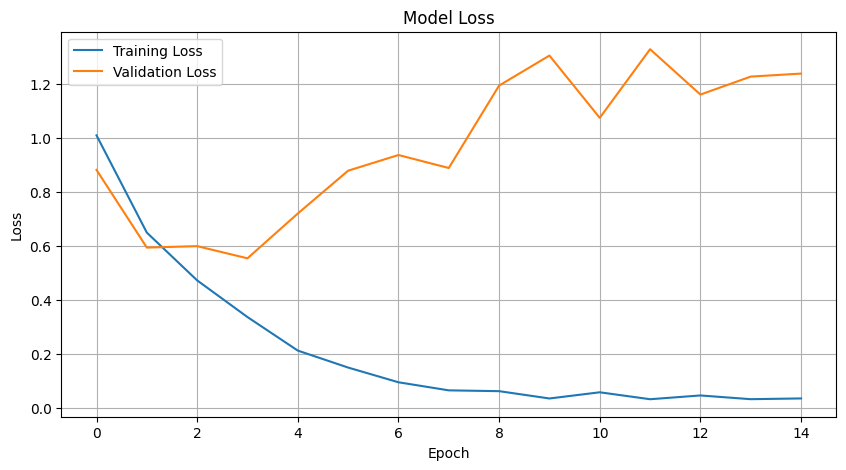

In [15]:
plot_training_history(history)


# Evaluate the Baseline Model

The training accuracy steadily increased and reached nearly 99%, while the validation accuracy stabilized around 80%.  
As shown in the accuracy and loss plots, the model performed well on the training data but showed signs of overfitting, as the validation loss increased after several epochs.  
The baseline model achieved a test accuracy of approximately 80.43%, which provides a solid starting point for further optimization using techniques like dropout, regularization, or data augmentation adjustments.

# Optimized Model Architecture

In this step, I recreated the data pipeline using ImageDataGenerator with an 80-20 split for training and validation.  
The training data was augmented using techniques such as rotation, zoom, shift, shear, and horizontal flip to improve generalization and reduce overfitting.  
The test data was only rescaled to maintain consistency during evaluation.  

Next, I implemented transfer learning using the VGG16 model pre-trained on ImageNet.  


In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

# ImageDataGenerator with Augmentation
datagen_with_split = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# NOTE: The test generator should NOT be augmented
test_datagen = ImageDataGenerator(rescale=1./255)

# ---  Recreate the data flows with the new generator ---
train_generator = datagen_with_split.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen_with_split.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


# Load the pre-trained VGG16 model

pre_trained_model = VGG16(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)

# We don't want to retrain the feature-finding layers
for layer in pre_trained_model.layers:
    layer.trainable = False

pre_trained_model.summary()

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

#Build and Compile the VGG16-Based Model

After loading the pre-trained VGG16 model, I built a new Sequential model by adding a Flatten layer, a Dense layer with 512 neurons and ReLU activation, followed by a Dropout layer (0.5) to reduce overfitting.  
The final output layer uses softmax activation with 6 neurons to match the number of classes.  

The model was compiled using the Adam optimizer with a learning rate of 0.0001, categorical cross-entropy loss, and accuracy as the evaluation metric.  


In [23]:
model_vgg = tf.keras.models.Sequential([
    pre_trained_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation='softmax')
])

In [24]:
model_vgg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [25]:
history_vgg = model_vgg.fit(
    train_generator_aug,
    epochs=20, # We can set a higher max epochs, EarlyStopping will stop it when needed
    validation_data=validation_generator,
    callbacks=[early_stopping], # <-- Add the callback here
    verbose=1
)

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 124s 274ms/step - accuracy: 0.6297 - loss: 0.9612 - val_accuracy: 0.8217 - val_loss: 0.5063
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 113s 257ms/step - accuracy: 0.7954 - loss: 0.5486 - val_accuracy: 0.8302 - val_loss: 0.4756
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 111s 253ms/step - accuracy: 0.8073 - loss: 0.5250 - val_accuracy: 0.8249 - val_loss: 0.4562
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 112s 255ms/step - accuracy: 0.8144 - loss: 0.4965 - val_accuracy: 0.8224 - val_loss: 0.4699
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 111s 252ms/step - accuracy: 0.8183 - loss: 0.4872 - val_accuracy: 0.8288 - val_loss: 0.4376
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 112s 254ms/step - accuracy: 0.8284 - loss: 0.4580 - val_accuracy: 0.8552 - val_loss: 0.4015
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 111s 252ms/step - accuracy: 0.8247 - loss: 0.4607 - val_accuracy: 0.8524 - val_loss: 0.4011
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 111s 254ms/step - accuracy: 0.8316 -

In [26]:
final_loss, final_accuracy = model_vgg.evaluate(test_generator)
print(f"\nFinal Model Accuracy on Test Data: {final_accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8811 - loss: 0.3221

Final Model Accuracy on Test Data: 87.47%


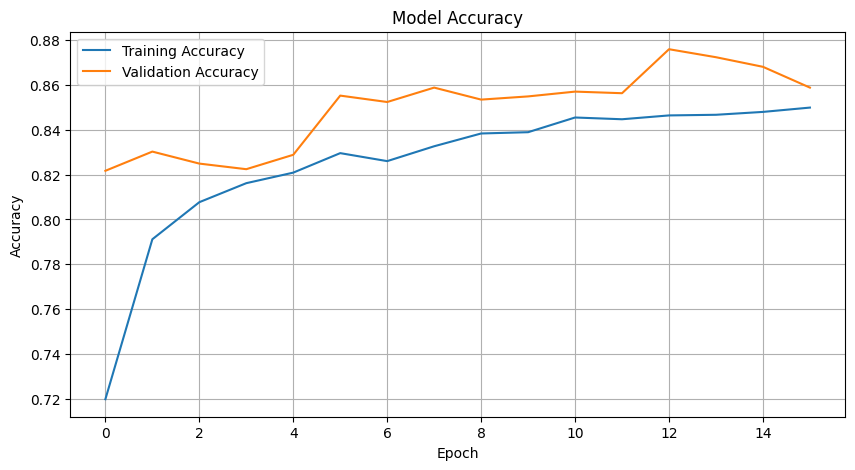

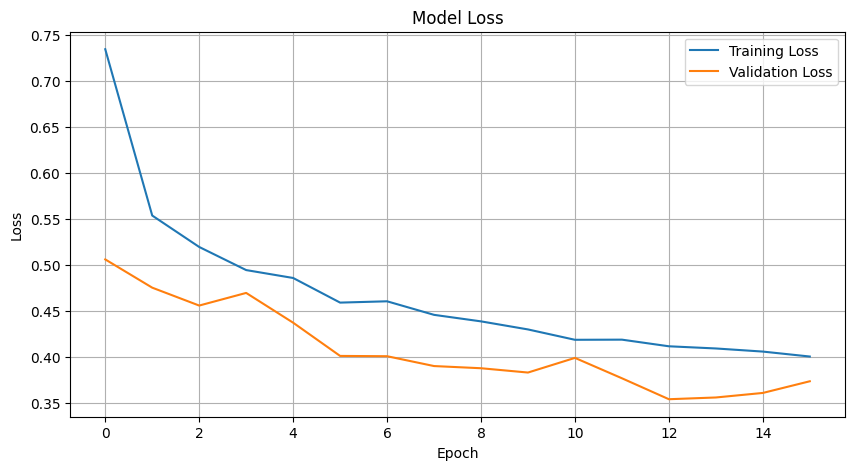

In [27]:
plot_training_history(history_vgg)


# Evaluation of the VGG16 Model

The VGG16-based model was trained for up to 20 epochs with early stopping to prevent overfitting.  
Both training and validation accuracy showed steady improvement, with the validation accuracy reaching around 87%.  
The training and validation loss curves indicate consistent learning and minimal overfitting due to the use of dropout and data augmentation.  

When evaluated on the test dataset, the final model achieved an accuracy of approximately 87.47% and a loss of 0.32.  
This shows a significant improvement compared to the baseline CNN model and confirms that using transfer learning with VGG16 effectively enhances classification accuracy.

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step


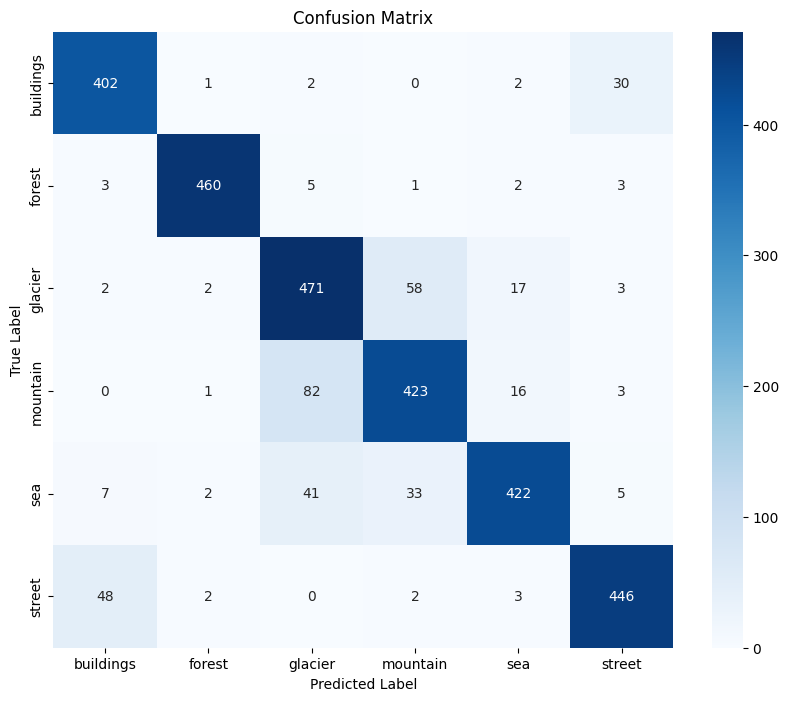


Classification Report:
              precision    recall  f1-score   support

   buildings       0.87      0.92      0.89       437
      forest       0.98      0.97      0.98       474
     glacier       0.78      0.85      0.82       553
    mountain       0.82      0.81      0.81       525
         sea       0.91      0.83      0.87       510
      street       0.91      0.89      0.90       501

    accuracy                           0.87      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.87      0.88      3000



In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

true_labels = []
# It's important to reset the generator before using it for predictions
test_generator.reset()
for i in range(len(test_generator)):
    _, labels = test_generator[i]
    true_labels.extend(np.argmax(labels, axis=1))

# 2. Make predictions on the test set
test_generator.reset() # Reset generator again for predictions
predictions = model_vgg.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# 3. Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
class_names = list(test_generator.class_indices.keys())

# 4. Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Print a classification report for more details (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# Model Evaluation Results
The confusion matrix shows that the model accurately predicted most classes, with slight confusion between visually similar categories such as glacier and mountain.  
The classification report indicates strong results across all six categories, achieving high precision and recall scores.  

Overall, the model reached an accuracy of 87% on the test set, with a macro F1-score of 0.88.  
This demonstrates that the VGG16-based model performs consistently well across all scene classes, making it an effective approach for image classification in this dataset.

# Visualizing Incorrect Predictions

Displaying 3 random incorrect predictions...


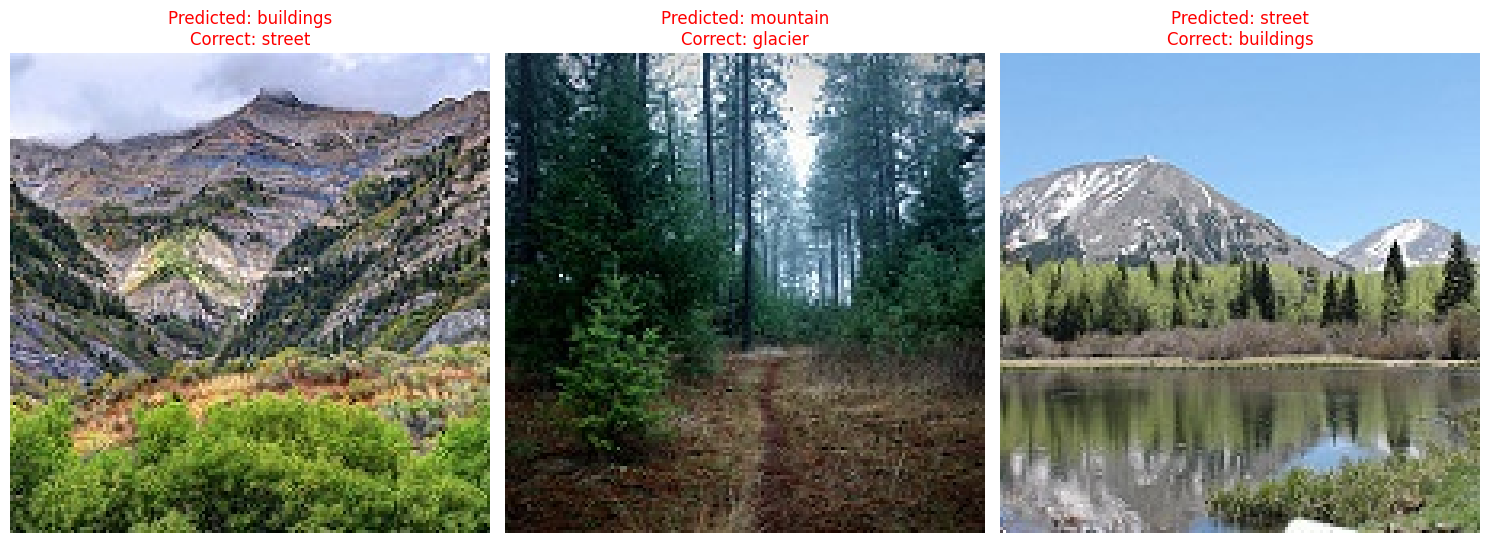

In [36]:

import matplotlib.image as mpimg

incorrect_indices = np.where(predicted_labels != true_labels)[0]

if len(incorrect_indices) >= 3:
    random_indices = random.sample(list(incorrect_indices), 3)

    print("Displaying 3 random incorrect predictions...")

    plt.figure(figsize=(15, 6)) # Create a figure to hold the subplots
    for i, index in enumerate(random_indices):
        image_filename = test_generator.filenames[index]
        predicted_class_index = predicted_labels[index]
        true_class_index = true_labels[index]

        predicted_class_name = class_names[predicted_class_index]
        true_class_name = class_names[true_class_index]

        full_image_path = os.path.join(test_dir, image_filename)

        img = mpimg.imread(full_image_path)

        # Create a subplot for each image
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Predicted: {predicted_class_name}\n"
                  f"Correct: {true_class_name}",
                  color='red', fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

elif len(incorrect_indices) > 0:
    print(f"Only found {len(incorrect_indices)} incorrect prediction(s), displaying all of them.")
else:
    print("Amazing! No incorrect predictions were found.")

While analyzing the model's errors, I discovered potential data quality issues within the test set itself. For example, the model classified the image above as 'buildings,' but the dataset's ground truth label was 'street' which was supposed to ne 'mountain'. This indicates that some images may be mislabeled in the original dataset, which could slightly affect the final accuracy metrics.




# Analysis Of Results
The VGG16 transfer learning model achieved about 87% test accuracy, improving from the baseline CNN’s 80%.
Using pre-trained VGG16 layers helped extract better features and boost classification performance.
Most classes showed high precision and recall, especially forest, sea, and street, though some confusion remained between glacier and mountain due to visual similarities.
The overall F1-score of 0.88 shows strong and balanced performance across all classes.
Some mislabeled images in the dataset may have slightly affected the final accuracy.